In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("carrie1/ecommerce-data")

print("Path to dataset files:", path)

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/andrewmoritz/.cache/kagglehub/datasets/carrie1/ecommerce-data/versions/1


In [4]:
commerce_df=pd.read_csv('commerce_data.csv', encoding= 'latin1')
commerce_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Data Cleaning and preprocessing

In [5]:
commerce_df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
def description_nulls(dataframe):
    """
    In this function we will attempt to replace all na
    values in Description with 'Not Provided'
    """
    commerce_df['Description']= commerce_df['Description'].fillna('Not Provided')
    return dataframe

description_nulls(commerce_df)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [7]:
def customer_null(dataframe):
    """
    This function will replace all null values in the CustomerId with
    the previous value to give us as many accurate values as possible
    """
    commerce_df['CustomerID']=commerce_df['CustomerID'].ffill()
    return dataframe

customer_null(commerce_df)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [8]:
# now we want to recreate the commerce dataframe so that it only has numerics and we can peform K means
# The new dataframe will feature 3 values for each customer: number of orders, total quantity and total spent
commerce_df['TotalPrice'] = commerce_df['Quantity'] * commerce_df['UnitPrice']

commerce_df = commerce_df.groupby('CustomerID', as_index=False).agg({
    'InvoiceNo': 'nunique',   
    'Quantity': 'sum',       
    'TotalPrice': 'sum'       
}).rename(columns={
    'InvoiceNo': 'num_orders',
    'Quantity': 'total_quantity',
    'TotalPrice': 'total_spent'
})

In [9]:
commerce_df.head()

,CustomerID,num_orders,total_quantity,total_spent
0,12346.0,2,0,0.00
1,12347.0,7,2458,4310.00
2,12348.0,5,2745,3366.27
3,12349.0,1,631,1757.55
4,12350.0,1,197,334.40


In [10]:
commerce_df.dtypes

CustomerID        float64
num_orders          int64
total_quantity      int64
total_spent       float64
dtype: object

In [11]:
# 2. Kmeans
X = commerce_df.drop('CustomerID',axis=1)
y = commerce_df['CustomerID']






In [12]:
# inertia elbow method to determine number of clusters
inertias = []

for k in range(1,10):
    model = KMeans(n_clusters=k).fit(X)
    distance = cdist(X, model.cluster_centers_,
                        'euclidean')
    inertia = model.inertia_
    inertias.append(inertia)

Text(0.5, 1.0, 'Elbow Method with Inertia')

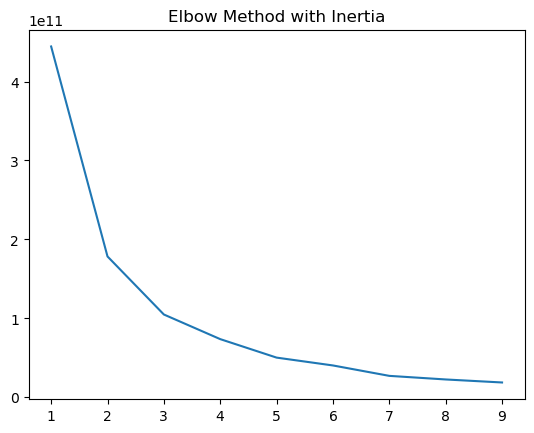

In [13]:
plt.plot(range(1,10), inertias)
plt.title('Elbow Method with Inertia')
# we will use 3 clusters as that is where the elbow is

In [ ]:
model = KMeans(n_clusters=3)
model.fit(X)


KMeans(n_clusters=3)


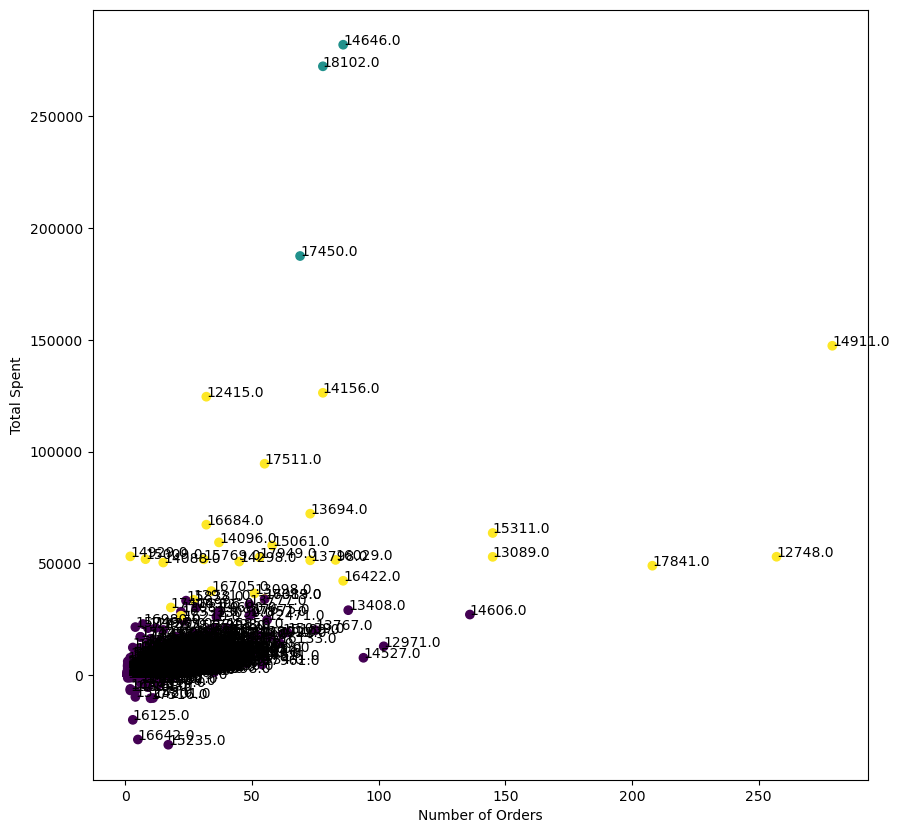

In [15]:
plt.figure(figsize=(10,10))
plt.scatter(X['num_orders'],X['total_spent'],c=model.labels_)
for i, txt in enumerate(y):
    plt.annotate(txt, (X['num_orders'][i],X['total_spent'][i]))

plt.xlabel('Number of Orders')
plt.ylabel('Total Spent')
plt.show()

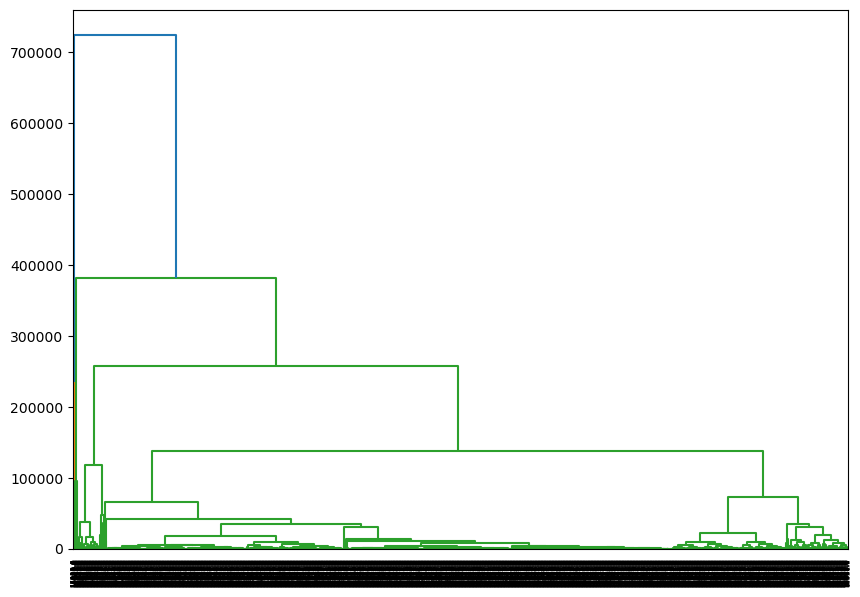

In [ ]:
# 3. hyerarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X, 'ward')
plt.figure(figsize=(10,7))

dendro = dendrogram(linked, labels = list(y))


In [25]:
from sklearn.cluster import AgglomerativeClustering



In [26]:
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster.fit_predict(X)

array([0, 0, 0, ..., 0, 0, 0], shape=(4372,))

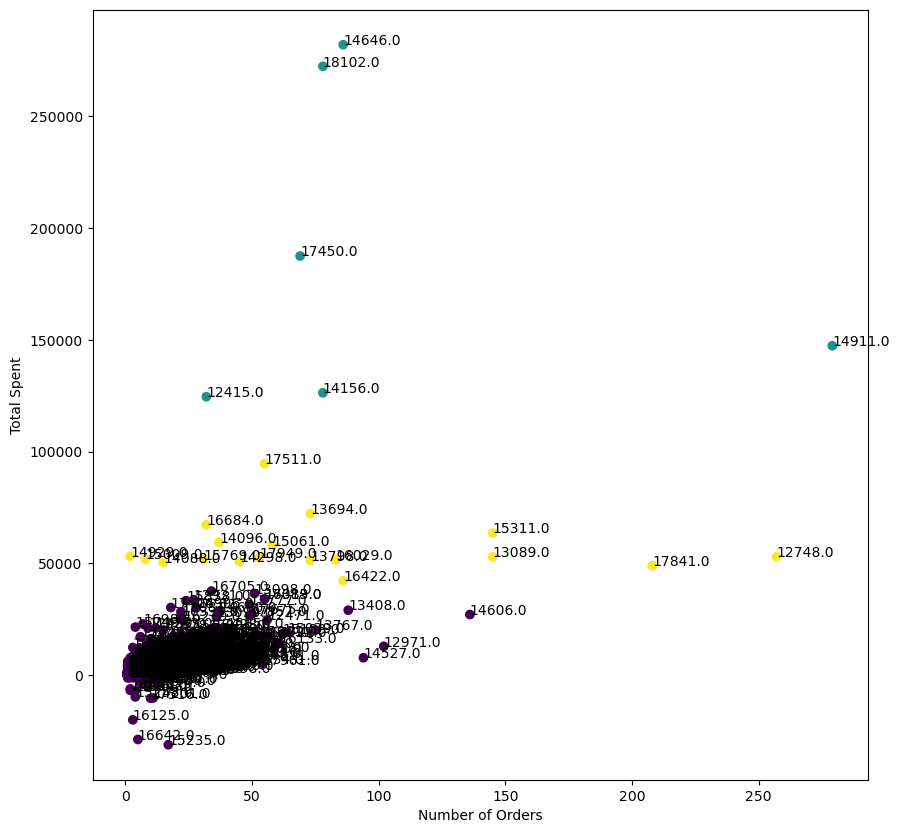

In [27]:
plt.figure(figsize=(10,10))
plt.scatter(X['num_orders'],X['total_spent'],c=cluster.labels_)
for i, txt in enumerate(y):
    plt.annotate(txt, (X['num_orders'][i],X['total_spent'][i]))

plt.xlabel('Number of Orders')
plt.ylabel('Total Spent')
plt.show()

In [ ]:
# 4. When looking at the results of 2 and 3 they seem to yield similar results. While both seem to be effective, hierarchical may be better for something like this as it as it clear more clearly breaks into groups of high, low and medium spenders